# M9 · Cold-start, Transfer & Distillation — Hands-on, Step by Tiny Step

**Companion to lesson M9. Written for someone new to ML.**

Every model faces a moment when it has **almost no data** but the product still has to
decide: a brand-new ad, a first-time visitor, a just-launched surface. That's **cold-start**.
This notebook shows the safe pattern — start from a **prior**, then hand off to the
**learned model** only once the evidence is strong enough — and then two ways to *reuse*
knowledge so you need fewer labels: **transfer learning** and **distillation**.

**What you'll do (every step has an explanation, logging, and a picture):**
- **Part A · Cold-start & the confidence blend:** why an early "2 clicks / 20 impressions"
  is a lie, how the blend `p = (1-c)·prior + c·learned` with `c = n/(n+k)` bridges safely,
  the exit criteria, and why this protects ad **budgets**.
- **Part B · Transfer learning:** with only a few labels a from-scratch model flounders —
  reuse a model trained on a related task and watch it recover. Plus **negative transfer**.
- **Part C · Distillation:** train a small, fast **student** to imitate a strong, slow
  **teacher** — including **temperature** and "dark knowledge," and the quality-vs-latency
  tradeoff.

We use **scikit-learn** + **matplotlib** (no installs in Colab). Run each cell with
**Shift+Enter**.

## Step 1 · Setup

Just imports and a couple of colors. Each later step explains the ML idea before its code.

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
plt.rcParams.update({"axes.grid": True, "grid.alpha": .3, "figure.autolayout": True})
BLUE, GREEN, RED, PURPLE, GOLD, GRAY = "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", "#888"
print("ready")

ready


---
# Part A · Cold-start & the confidence blend

## Step 2 · What is cold-start? (and the trap)

**Cold-start** = the model has (almost) no history for something new. Three flavors:

| Type | What's missing | Example |
|---|---|---|
| **New item** | item interaction history | a brand-new Event Ad |
| **New user** | user history | a first-session visitor |
| **New system** | reliable labels | a just-launched surface |

The trap: a new ad gets **2 clicks in 20 impressions** — a raw CTR of **10%**. That looks
amazing, but 20 impressions is almost no evidence. If pacing believes it, budget floods a
noisy fluke. Let's *see* how unreliable a 20-impression rate is.

true CTR of every ad: 0.01  (1%)
yet observed 20-impression CTRs range from 0.0 to 0.15
share of ads that look like >=10% CTR by luck: 0.017


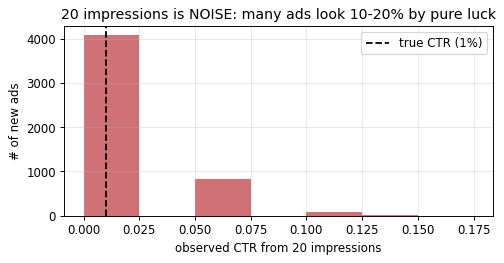

In [5]:
rng = np.random.default_rng(0)
true_ctr = 0.01                       # the REAL click rate for these new ads is a boring 1%
n_imps   = 20                         # but each new ad has only 20 impressions so far
observed = rng.binomial(n_imps, true_ctr, size=5000) / n_imps   # 5000 new ads' observed CTRs

print("true CTR of every ad:", true_ctr, " (1%)")
print("yet observed 20-impression CTRs range from", observed.min(), "to", observed.max())
print("share of ads that look like >=10% CTR by luck:", round((observed >= 0.10).mean(), 3))
plt.figure(figsize=(6,3.2))
plt.hist(observed, bins=np.arange(0, observed.max()+0.026, 0.025), color=RED, alpha=.8)
plt.axvline(true_ctr, color="k", ls="--", label="true CTR (1%)")
plt.xlabel("observed CTR from 20 impressions"); plt.ylabel("# of new ads"); plt.legend()
plt.title("20 impressions is NOISE: many ads look 10-20% by pure luck"); plt.show()

## Step 3 · The safe anchor — a **prior**

Instead of trusting 2/20, start from what **similar** items usually do. A **category prior**
might say "ads in this category average **1%** CTR." It's boring, but stable — it doesn't
swing with a couple of lucky clicks. Cold-start begins here.

In [7]:
p_prior = 0.01
print("category prior CTR:", p_prior, "-> our safe starting guess for ANY brand-new ad")
print("compare: the noisy '2 clicks / 20 impressions' raw estimate =", 2/20, "(way too hot)")

category prior CTR: 0.01 -> our safe starting guess for ANY brand-new ad
compare: the noisy '2 clicks / 20 impressions' raw estimate = 0.1 (way too hot)


## Step 4 · The confidence blend — the key formula

We don't want to ignore the ad's own data forever — just to **trust it in proportion to how
much of it there is**. The blend:
$$\hat p = (1-c_n)\,p_\text{prior} + c_n\,p_\text{learned},\qquad c_n=\frac{n}{n+k}$$
`c_n` is a **confidence dial** from 0 to 1. With `n` impressions and a constant `k`:
- tiny `n` → `c_n≈0` → we mostly trust the **prior**,
- huge `n` → `c_n≈1` → we mostly trust the ad's **own learned rate**.
`k` sets "how much evidence before I start trusting the data." Let's plot the dial.

  n=  20: c_n = 0.020
  n= 100: c_n = 0.091
  n=1000: c_n = 0.500
  n=5000: c_n = 0.833


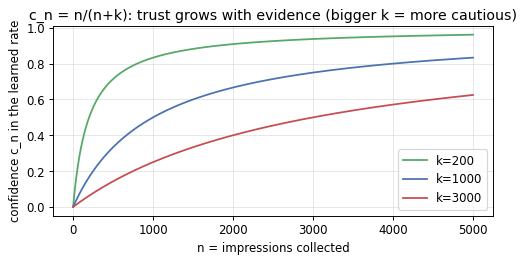

In [9]:
k = 1000
n = np.arange(0, 5001)
plt.figure(figsize=(6,3.2))
for kk, c in [(200, GREEN), (1000, BLUE), (3000, RED)]:
    plt.plot(n, n/(n+kk), color=c, label=f"k={kk}")
plt.xlabel("n = impressions collected"); plt.ylabel("confidence c_n in the learned rate")
plt.title("c_n = n/(n+k): trust grows with evidence (bigger k = more cautious)"); plt.legend(); plt.show()
for nv in [20, 100, 1000, 5000]:
    print(f"  n={nv:>4}: c_n = {nv/(nv+k):.3f}")

## Step 5 · The worked example from the lesson

Plug in the lesson's numbers: `p_prior=1%`, `p_learned=10%` (the hot 2/20 rate), `n=20`,
`k=1000`. The blend should stay near **1.18%**, *not* 10% — the 20 impressions barely move
us off the prior. Verify it exactly.

In [11]:
p_prior, p_learned, n, k = 0.010, 0.100, 20, 1000
c_n = n / (n + k)
p_blend = (1 - c_n) * p_prior + c_n * p_learned
print(f"c_n = {n}/({n}+{k}) = {c_n:.4f}")
print(f"blend = (1-{c_n:.4f})*{p_prior} + {c_n:.4f}*{p_learned} = {p_blend:.4f}  ({p_blend*100:.2f}%)")
assert round(p_blend, 4) == 0.0118
print("matches the lesson's 1.18% ✓  -> the early spike is tamed")

c_n = 20/(20+1000) = 0.0196
blend = (1-0.0196)*0.01 + 0.0196*0.1 = 0.0118  (1.18%)
matches the lesson's 1.18% ✓  -> the early spike is tamed


## Step 6 · Watch the handoff happen

Now follow **one** ad as impressions accumulate (true CTR 10%). Plot three lines:
- **prior** (flat 1%),
- **raw** running CTR (jumpy early, settles late),
- **blended** estimate — starts glued to the prior, then smoothly slides toward the truth.
This is the cold→warm handoff in one picture.

  n=  20: raw=0.100  blended=0.012  c_n=0.02
  n= 100: raw=0.110  blended=0.019  c_n=0.09
  n= 500: raw=0.104  blended=0.041  c_n=0.33
  n=1000: raw=0.080  blended=0.045  c_n=0.50
  n=3000: raw=0.093  blended=0.072  c_n=0.75


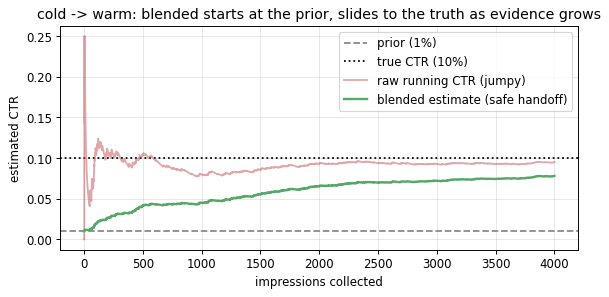

In [13]:
rng = np.random.default_rng(2)
true_ctr, p_prior, k = 0.10, 0.01, 1000
N = 4000
clicks = (rng.random(N) < true_ctr).astype(int)
imps = np.arange(1, N+1)
raw = np.cumsum(clicks) / imps
c_n = imps / (imps + k)
blend = (1 - c_n) * p_prior + c_n * raw

plt.figure(figsize=(7,3.6))
plt.axhline(p_prior, color=GRAY, ls="--", label="prior (1%)")
plt.axhline(true_ctr, color="k", ls=":", label="true CTR (10%)")
plt.plot(imps, raw, color=RED, alpha=.5, label="raw running CTR (jumpy)")
plt.plot(imps, blend, color=GREEN, lw=2, label="blended estimate (safe handoff)")
plt.xlabel("impressions collected"); plt.ylabel("estimated CTR"); plt.legend()
plt.title("cold -> warm: blended starts at the prior, slides to the truth as evidence grows"); plt.show()
for nv in [20, 100, 500, 1000, 3000]:
    print(f"  n={nv:>4}: raw={raw[nv-1]:.3f}  blended={blend[nv-1]:.3f}  c_n={c_n[nv-1]:.2f}")

## Step 7 · Exit criteria — log the regime, gate the handoff

Don't switch on a hunch. Define **gates** and label every score with the **regime** that
produced it, so later you can tell "the model is bad" from "we handed off too early":
- **cold** (trust prior) → **blended** → **warm** (trust learned) once, e.g., **≥1000
  impressions AND ≥20 clicks** with stable calibration.

     20 imps /   2 clicks  ->  regime = cold
    300 imps /   8 clicks  ->  regime = blended
   1200 imps /  25 clicks  ->  regime = warm
   5000 imps /  90 clicks  ->  regime = warm


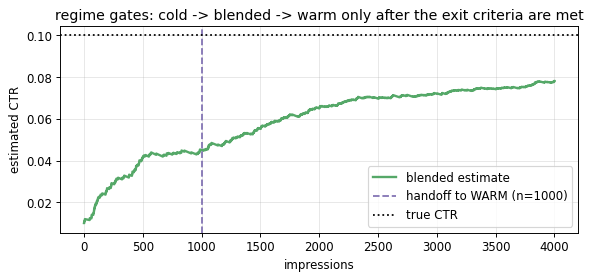

In [15]:
def regime(n_imps, n_clicks):
    if n_imps >= 1000 and n_clicks >= 20:
        return "warm"
    if n_imps >= 50:
        return "blended"
    return "cold"

for n_imps, n_clicks in [(20, 2), (300, 8), (1200, 25), (5000, 90)]:
    print(f"  {n_imps:>5} imps / {n_clicks:>3} clicks  ->  regime = {regime(n_imps, n_clicks)}")

cum_clicks = np.cumsum(clicks)
regimes = [regime(i, cum_clicks[i-1]) for i in imps]
first_warm = regimes.index("warm") + 1
plt.figure(figsize=(7,3.4))
plt.plot(imps, blend, color=GREEN, lw=2, label="blended estimate")
plt.axvline(first_warm, color=PURPLE, ls="--", label=f"handoff to WARM (n={first_warm})")
plt.axhline(0.10, color="k", ls=":", label="true CTR")
plt.xlabel("impressions"); plt.ylabel("estimated CTR"); plt.legend()
plt.title("regime gates: cold -> blended -> warm only after the exit criteria are met"); plt.show()

## Step 8 · Why it matters — protecting the **budget**

Pacing multiplies CTR by bid to spend budget. If it uses the **raw** early rate, it pours
money into lucky spikes. The **blend** keeps every new ad near the prior until it earns
trust — so budget follows the ad with real, sustained evidence, not the noisiest fluke.

              ad  raw CTR  blended CTR
  spike A (2/20) 0.100000     0.011765
  spike B (3/20) 0.150000     0.012745
      dud (0/20) 0.000000     0.009804
proven (25/1500) 0.016667     0.014000
raw would overspend on the 15% spike; blended ranks the proven ad highest. Budget stays safe.


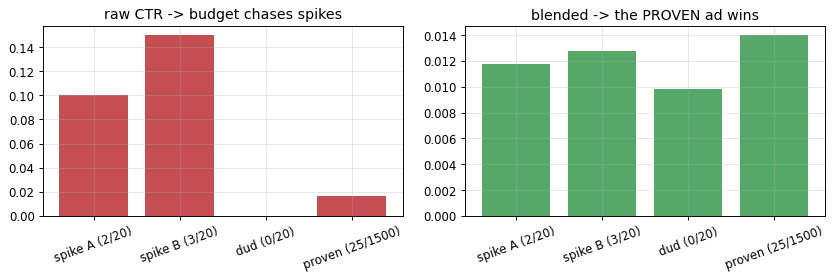

In [17]:
p_prior, k = 0.01, 1000
ads = [("spike A (2/20)", 2, 20), ("spike B (3/20)", 3, 20),
       ("dud (0/20)", 0, 20), ("proven (25/1500)", 25, 1500)]
rows = []
for name, c, n in ads:
    raw = c/n; cn = n/(n+k); bl = (1-cn)*p_prior + cn*raw
    rows.append((name, raw, bl))
df = pd.DataFrame(rows, columns=["ad", "raw CTR", "blended CTR"]); print(df.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
names = [r[0] for r in rows]
ax[0].bar(names, [r[1] for r in rows], color=RED);  ax[0].set_title("raw CTR -> budget chases spikes"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(names, [r[2] for r in rows], color=GREEN); ax[1].set_title("blended -> the PROVEN ad wins"); ax[1].tick_params(axis="x", rotation=20)
plt.show()
print("raw would overspend on the 15% spike; blended ranks the proven ad highest. Budget stays safe.")

---
# Part B · Transfer learning

## Step 9 · The setup — few target labels, a related source

**Transfer** = reuse a model trained on a **related task with lots of data** (the *source*)
to help a **new task with few labels** (the *target*). We build a hard, high-dimensional
task (40 features). The **source** model sees 40,000 labels; the **target** has only a
handful. First, how good is the source on its own?

In [20]:
D = 40
gen = np.random.default_rng(0)
w_true = gen.normal(0, 1, D) * np.array([1.0]*8 + [0.15]*32)   # 8 strong + 32 weak features
def make(n, seed, w=w_true):
    r = np.random.default_rng(seed); X = r.normal(0, 1, (n, D))
    y = (r.random(n) < 1/(1+np.exp(-(X @ w - 0.2)))).astype(int)
    return X, y

Xs, ys = make(40000, 1)                                  # SOURCE: plenty of labels
source = LogisticRegression(max_iter=2000).fit(Xs, ys)
Xte, yte = make(8000, 99)                                # shared test set
print("source model AUC (trained on 40k):", round(roc_auc_score(yte, source.predict_proba(Xte)[:,1]), 3))

source model AUC (trained on 40k): 0.86


## Step 10 · From-scratch flounders with few labels

Train a fresh model on only the target's few labels. With 40 features and ~100–200 rows it
**overfits** and generalizes poorly. Watch AUC climb only as labels pile up.

In [22]:
def scratch_auc(n_labels, seed=7):
    Xt, yt = make(n_labels, seed)
    m = LogisticRegression(max_iter=2000).fit(Xt, yt)
    return roc_auc_score(yte, m.predict_proba(Xte)[:,1])

label_counts = [100, 200, 500, 1000, 2000, 10000]
scratch = [scratch_auc(n) for n in label_counts]
for n, a in zip(label_counts, scratch):
    print(f"  {n:>6} labels -> scratch AUC {a:.3f}")

     100 labels -> scratch AUC 0.708
     200 labels -> scratch AUC 0.787
     500 labels -> scratch AUC 0.839
    1000 labels -> scratch AUC 0.846
    2000 labels -> scratch AUC 0.852
   10000 labels -> scratch AUC 0.859


## Step 11 · Transfer to the rescue

Simplest transfer: feed the **source model's prediction** (its logit) into the target model
as a ready-made, information-rich feature. Now the target only has to learn *how much to
trust* the source — one weight — so even **100 labels** get near the source's ceiling. Plot
the two learning curves.

     100 labels -> transfer AUC 0.860
     200 labels -> transfer AUC 0.860
     500 labels -> transfer AUC 0.860
    1000 labels -> transfer AUC 0.860
    2000 labels -> transfer AUC 0.860
   10000 labels -> transfer AUC 0.860


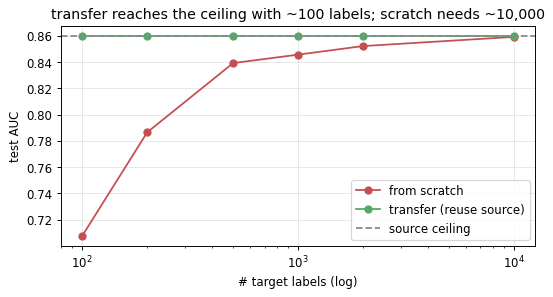

In [24]:
def src_feat(X):
    p = np.clip(source.predict_proba(X)[:,1], 1e-6, 1-1e-6)
    return np.log(p/(1-p)).reshape(-1, 1)                 # the source's logit as ONE feature

def transfer_auc(n_labels, seed=7):
    Xt, yt = make(n_labels, seed)
    m = LogisticRegression(max_iter=2000).fit(src_feat(Xt), yt)
    return roc_auc_score(yte, m.predict_proba(src_feat(Xte))[:,1])

transfer = [transfer_auc(n) for n in label_counts]
ceiling = roc_auc_score(yte, source.predict_proba(Xte)[:,1])
for n, a in zip(label_counts, transfer):
    print(f"  {n:>6} labels -> transfer AUC {a:.3f}")

plt.figure(figsize=(6.5,3.6))
plt.plot(label_counts, scratch, "o-", color=RED, label="from scratch")
plt.plot(label_counts, transfer, "o-", color=GREEN, label="transfer (reuse source)")
plt.axhline(ceiling, color=GRAY, ls="--", label="source ceiling")
plt.xscale("log"); plt.xlabel("# target labels (log)"); plt.ylabel("test AUC"); plt.legend()
plt.title("transfer reaches the ceiling with ~100 labels; scratch needs ~10,000"); plt.show()

## Step 12 · The catch — **negative transfer**

Transfer is a *hypothesis*, not a guarantee. If the source solved a **different** problem,
its signal is misleading and transfer does **worse than scratch**. We build a "mismatched"
source (trained toward unrelated weights) and reuse it — AUC collapses. Always validate the
source–target fit.

with 200 target labels:
  scratch                    AUC 0.787
  transfer from GOOD source   AUC 0.860  (helps)
  transfer from MISMATCHED src AUC 0.739  (hurts! negative transfer)


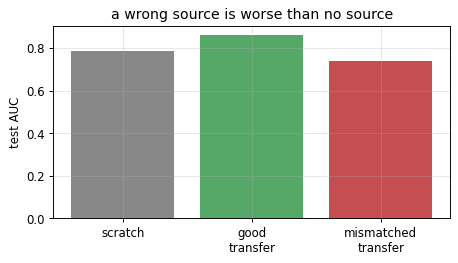

In [26]:
w_bad = np.random.default_rng(0).normal(0, 1, D)                 # a DIFFERENT objective
Xb, yb = make(40000, 2, w=w_bad)
bad_source = LogisticRegression(max_iter=2000).fit(Xb, yb)
def bad_feat(X):
    p = np.clip(bad_source.predict_proba(X)[:,1], 1e-6, 1-1e-6)
    return np.log(p/(1-p)).reshape(-1, 1)

Xt, yt = make(200, 7)
a_scratch  = roc_auc_score(yte, LogisticRegression(max_iter=2000).fit(Xt, yt).predict_proba(Xte)[:,1])
a_good     = roc_auc_score(yte, LogisticRegression(max_iter=2000).fit(src_feat(Xt), yt).predict_proba(src_feat(Xte))[:,1])
a_bad      = roc_auc_score(yte, LogisticRegression(max_iter=2000).fit(bad_feat(Xt), yt).predict_proba(bad_feat(Xte))[:,1])
print("with 200 target labels:")
print(f"  scratch                    AUC {a_scratch:.3f}")
print(f"  transfer from GOOD source   AUC {a_good:.3f}  (helps)")
print(f"  transfer from MISMATCHED src AUC {a_bad:.3f}  (hurts! negative transfer)")
plt.figure(figsize=(5.5,3.2))
plt.bar(["scratch","good\ntransfer","mismatched\ntransfer"], [a_scratch, a_good, a_bad], color=[GRAY, GREEN, RED])
plt.ylabel("test AUC"); plt.title("a wrong source is worse than no source"); plt.show()

---
# Part C · Distillation

## Step 13 · Teacher vs student

**Distillation** trains a small, **fast student** to imitate a big, **slow teacher**. Why?
The teacher may be too slow to serve online, or you may have lots of **unlabeled** traffic
the teacher can label cheaply. Here the teacher is a 400-tree gradient boosting model (strong
but heavy); the student will be a light logistic model. The task has a 3-way interaction and
a sine wave — signal the light student can only *partly* capture, so it will stay a bit below
the teacher (that's the quality/latency tradeoff).

In [29]:
from sklearn.ensemble import GradientBoostingClassifier
def make2(n, seed):
    r = np.random.default_rng(seed); X = r.normal(0, 1, (n, 8))
    logit = (1.3*X[:,0] - 1.0*X[:,1] + 1.2*X[:,2]*X[:,3]
             + 1.6*X[:,2]*X[:,3]*X[:,4] + 0.8*np.sin(2.5*X[:,5]) - 0.4*X[:,6] - 0.2)
    y = (r.random(n) < 1/(1+np.exp(-logit))).astype(int)
    return X, y

Xtest, ytest = make2(6000, 4)
teacher = GradientBoostingClassifier(max_depth=4, n_estimators=400).fit(*make2(25000, 10))
auc_teacher = roc_auc_score(ytest, teacher.predict_proba(Xtest)[:,1])
print("teacher AUC (strong, but slow to serve):", round(auc_teacher, 3))

teacher AUC (strong, but slow to serve): 0.855


## Step 14 · Temperature & "dark knowledge"

A **hard label** says only 0 or 1. The teacher's **probability** says much more: a negative
scored 0.45 is "almost a click," while 0.02 is "clearly not." That extra shading is **dark
knowledge**. **Temperature** `T` softens probabilities (divide the logit by `T`) to make the
shading easier for the student to see. Let's visualize the softening.

hard labels would be [1 1 0 0] - the student would never learn how 'close' B and C were.


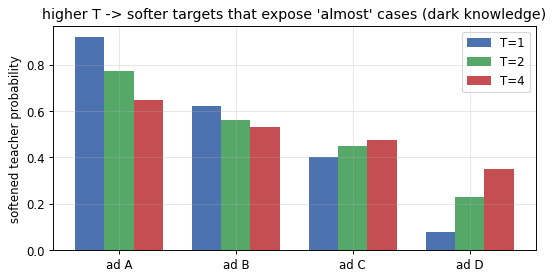

In [31]:
def soften(p, T):
    z = np.log(np.clip(p, 1e-6, 1-1e-6) / (1 - np.clip(p, 1e-6, 1-1e-6)))
    return 1 / (1 + np.exp(-z / T))

items = ["ad A", "ad B", "ad C", "ad D"]
p_teacher = np.array([0.92, 0.62, 0.40, 0.08])
xb = np.arange(len(items)); w = 0.25
plt.figure(figsize=(6.5,3.4))
for j, (T, c) in enumerate([(1, BLUE), (2, GREEN), (4, RED)]):
    plt.bar(xb + (j-1)*w, soften(p_teacher, T), w, color=c, label=f"T={T}")
plt.xticks(xb, items); plt.ylabel("softened teacher probability"); plt.legend()
plt.title("higher T -> softer targets that expose 'almost' cases (dark knowledge)"); plt.show()
print("hard labels would be", (p_teacher>0.5).astype(int), "- the student would never learn how 'close' B and C were.")

## Step 15 · Distill — the teacher teaches the student

Two students, both light logistic models (with interaction features so they *can* learn a
bit):
- **hard student:** trained on only **400 hard labels** → overfits, underperforms.
- **distilled student:** the teacher labels a big **unlabeled pool (20,000 rows)** with soft
  scores; the student learns from those. It sees far more supervision → much better AUC,
  approaching (but below) the teacher.

teacher (strong/slow)          AUC 0.855
student, 400 HARD labels       AUC 0.773
student, 20k teacher SOFT labels AUC 0.817  (+0.044 over hard)


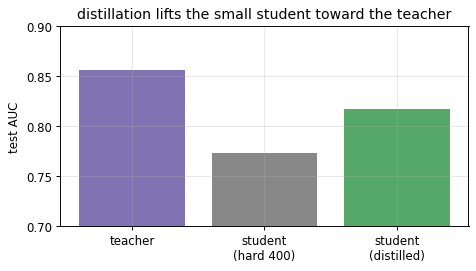

In [33]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

def student_clf():   # small + fast: interaction features + logistic
    return make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                         LogisticRegression(max_iter=4000, C=0.5))
def student_reg():   # same shape, regresses onto teacher logits
    return make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(), Ridge(alpha=1.0))

Xhard, yhard = make2(400, 3)                         # few hard labels
hard = student_clf().fit(Xhard, yhard)
auc_hard = roc_auc_score(ytest, hard.predict_proba(Xtest)[:,1])

Xpool, _ = make2(20000, 5)                           # big UNLABELED pool
soft = np.clip(teacher.predict_proba(Xpool)[:,1], 1e-6, 1-1e-6)
distilled = student_reg().fit(Xpool, np.log(soft/(1-soft)))   # learn the teacher's soft logits
auc_distilled = roc_auc_score(ytest, distilled.predict(Xtest))

print(f"teacher (strong/slow)          AUC {auc_teacher:.3f}")
print(f"student, 400 HARD labels       AUC {auc_hard:.3f}")
print(f"student, 20k teacher SOFT labels AUC {auc_distilled:.3f}  (+{auc_distilled-auc_hard:.3f} over hard)")
plt.figure(figsize=(5.8,3.3))
plt.bar(["teacher","student\n(hard 400)","student\n(distilled)"], [auc_teacher, auc_hard, auc_distilled],
        color=[PURPLE, GRAY, GREEN])
plt.ylabel("test AUC"); plt.ylim(0.7, 0.9); plt.title("distillation lifts the small student toward the teacher"); plt.show()

## Step 16 · The quality-vs-latency tradeoff

The distilled student is a little **below** the teacher but **much cheaper to serve**. That
trade can be a win: if latency is the bottleneck, a 5 ms student at slightly lower AUC beats
a 40 ms teacher you can't afford to run online. (The ms numbers below are illustrative,
matching the lesson.)

teacher: AUC 0.855 @ ~40 ms   vs   student: AUC 0.817 @ ~5 ms (~8x faster)


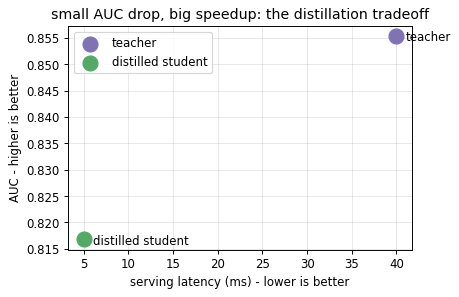

In [35]:
serving_ms = {"teacher": 40, "distilled student": 5}
aucs       = {"teacher": auc_teacher, "distilled student": auc_distilled}
plt.figure(figsize=(5.5,3.6))
for name, c in [("teacher", PURPLE), ("distilled student", GREEN)]:
    plt.scatter(serving_ms[name], aucs[name], s=160, color=c, label=name, zorder=3)
    plt.annotate(name, (serving_ms[name], aucs[name]), textcoords="offset points", xytext=(8, -4))
plt.xlabel("serving latency (ms) - lower is better"); plt.ylabel("AUC - higher is better")
plt.title("small AUC drop, big speedup: the distillation tradeoff"); plt.legend(); plt.show()
print(f"teacher: AUC {auc_teacher:.3f} @ ~40 ms   vs   student: AUC {auc_distilled:.3f} @ ~5 ms (~8x faster)")

## Step 17 · The catch — distillation copies the teacher's bias

Distillation makes serving cheaper; it does **not** fix a bad teacher. If the teacher learned
from a biased policy, the student inherits that bias. So keep the teacher as an offline
reference, check student-vs-teacher disagreement on important slices, and **recalibrate**
(Part of M8) — matching logits doesn't guarantee good serving probabilities.

correlation between teacher and student scores: 0.895 -> student mimics the teacher (bias included)


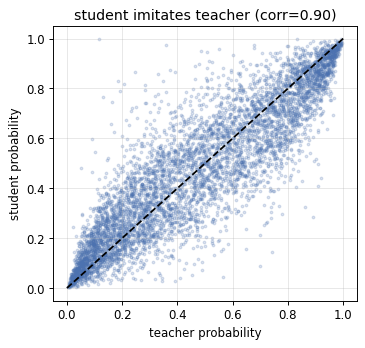

In [37]:
# the student closely tracks the teacher's ranking -> it also copies whatever the teacher got wrong
p_t = teacher.predict_proba(Xtest)[:,1]
p_s = 1/(1+np.exp(-distilled.predict(Xtest)))
corr = np.corrcoef(p_t, p_s)[0,1]
print("correlation between teacher and student scores:", round(corr, 3), "-> student mimics the teacher (bias included)")
plt.figure(figsize=(4.4,4.2))
plt.scatter(p_t, p_s, s=5, alpha=.2, color=BLUE)
plt.plot([0,1],[0,1],"k--"); plt.xlabel("teacher probability"); plt.ylabel("student probability")
plt.title(f"student imitates teacher (corr={corr:.2f})"); plt.show()

---
## Recap — the M9 toolkit

**Cold-start (Part A).** New items/users/systems have almost no evidence, so a raw early rate
(2/20 = 10%) is noise. Anchor on a **prior**, then blend in the learned rate in proportion to
evidence: `p = (1-c)·prior + c·learned` with `c = n/(n+k)`. Gate the cold→warm handoff with
**exit criteria** (min impressions, min positives, stable calibration) and log the regime.
This is what keeps ad **budgets** from chasing lucky spikes.

**Transfer (Part B).** With few target labels, a from-scratch model flounders. **Reuse a
related source** (here, its prediction as a feature) to reach the ceiling with ~100 labels
instead of ~10,000 — but validate fit, because a mismatched source causes **negative
transfer** (worse than scratch).

**Distillation (Part C).** Train a small, fast **student** to imitate a strong, slow
**teacher**. **Temperature** exposes the teacher's **dark knowledge** (how "close" the
negatives were), and letting the teacher label a big **unlabeled pool** lifts the student
well above training on a few hard labels — at a fraction of the serving cost. It copies the
teacher's **bias**, so keep evaluating slices and recalibrate.

**Where this connects:** M9 is how you launch responsibly with little data. It leans on M8
(calibrate the blended/distilled scores) and feeds M10 (the implicit, delayed labels these
systems learn from as evidence finally arrives).